# Tugas Praktikum 1: Web Scraping & Exploratory Data Analysis (EDA)
- **Sumber Data**: Books to Scrape (https://books.toscrape.com/)
- **Jumlah Data**: 1000 Buku (20 Halaman Catalog)
- **Library**: `requests`, `bs4 (BeautifulSoup)`, `pandas`, `matplotlib`, `seaborn`, `numpy`

**Nama:** Catherine Aprilia Harlina  
**NRP:** 5054251012  
**Mata Kuliah:** Data Mining / Rekayasa Kecerdasan Artifisial (ITS)

In [13]:
%pip install -q beautifulsoup4 requests pandas matplotlib seaborn numpy
import requests, re, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlsplit, urlunsplit
from urllib.robotparser import RobotFileParser
print("Library berhasil diimpor.")

Note: you may need to restart the kernel to use updated packages.
Library berhasil diimpor.


In [14]:
BASE_URL, USER_AGENT = "https://books.toscrape.com/", "DM-PracticeBot/1.0"
def diizinkan_robots(url):
    p = urlsplit(url)
    rb_url = urlunsplit((p.scheme, p.netloc, "/robots.txt", "", ""))
    try:
        res = requests.get(rb_url, headers={"User-Agent": USER_AGENT}, timeout=10)
        if 400 <= res.status_code < 500: return True
        res.raise_for_status()
    except requests.RequestException: return True
    rfp = RobotFileParser()
    rfp.set_url(rb_url); rfp.parse(res.text.splitlines())
    return rfp.can_fetch(USER_AGENT, url)

print("Status Izin Scraping:", diizinkan_robots(BASE_URL))

Status Izin Scraping: True


In [15]:
RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

def scrape_books_to_scrape():
    if not diizinkan_robots(BASE_URL): raise PermissionError("Akses dilarang oleh robots.txt")
    data, curr_url = [], urljoin(BASE_URL, "catalogue/page-1.html")
    while curr_url:
        res = requests.get(curr_url, headers={"User-Agent": USER_AGENT}, timeout=10)
        if res.status_code != 200: break
        soup = BeautifulSoup(res.text, "html.parser")
        for article in soup.select("article.product_pod"):
            title = article.h3.a["title"].strip()
            price_raw = article.select_one("p.price_color").get_text(strip=True)
            price = float(re.sub(r"[^\d.]", "", price_raw))
            rating_cls = article.select_one("p.star-rating")["class"]
            rating = RATING_MAP.get(next((c for c in rating_cls if c != "star-rating"), None), np.nan)
            availability = article.select_one("p.instock.availability").get_text(strip=True)
            book_url = urljoin(curr_url, article.h3.a["href"])
            data.append({"judul": title, "harga_gbp": price, "rating": rating, "ketersediaan": availability, "url": book_url})
        next_elm = soup.select_one("li.next > a")
        curr_url = urljoin(curr_url, next_elm["href"]) if next_elm else None
    return pd.DataFrame(data)

df_raw = scrape_books_to_scrape()
df_raw.to_csv("books_scraped_raw.csv", index=False, encoding="utf-8")
print(f"Scraping selesai. Total data diperoleh: {len(df_raw)} baris. Disimpan ke 'books_scraped_raw.csv'.")

Scraping selesai. Total data diperoleh: 1000 baris. Disimpan ke 'books_scraped_raw.csv'.


In [20]:
df = pd.read_csv("books_scraped_raw.csv")
print("5 BARIS PERTAMA"); display(df.head())
print("\nINFORMASI DATASET"); df.info()
print("\nSHAPE DATASET : ", df.shape)

5 BARIS PERTAMA


,judul,harga_gbp,rating,ketersediaan,url
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...



INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   judul         1000 non-null   str    
 1   harga_gbp     1000 non-null   float64
 2   rating        1000 non-null   int64  
 3   ketersediaan  1000 non-null   str    
 4   url           1000 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 172.3 KB

SHAPE DATASET :  (1000, 5)


### Identifikasi Tipe Atribut:
1. **`judul`**: nominal (Teks identitas/nama buku)
2. **`harga_gbp`**: numerik Kontinu (Rasio, nilai mata uang Pounds £)
3. **`rating`**: ordinal / numerik Diskrit (Skala tingkatan bintang 1 sampai 5)
4. **`ketersediaan`**: nominal / biner (kategori status ketersediaan barang)
5. **`url`**: nominal (tautan ke halaman detail produk)

In [17]:
# 1. Statistik Deskriptif Numerik
print("Statistik Deskriptif Numerik:")
s_num = df[["harga_gbp", "rating"]].describe().T
s_num["median"] = df[["harga_gbp", "rating"]].median()
s_num["mode"] = df[["harga_gbp", "rating"]].mode().iloc[0]
s_num["std_dev"] = df[["harga_gbp", "rating"]].std()
display(s_num[["mean", "median", "mode", "std_dev", "min", "max"]].round(2))

# 2. Frekuensi Atribut Kategorikal
print("\nFrekuensi Atribut Kategorikal:")
display(df["ketersediaan"].value_counts().to_frame(name="jumlah"))

# 3. Deteksi Missing Value
print("\nDeteksi Missing Value:")
display(df.isna().sum().to_frame(name="missing_count"))

# 4. Deteksi Outlier (IQR)
q1, q3 = df["harga_gbp"].quantile(0.25), df["harga_gbp"].quantile(0.75)
iqr = q3 - q1
outliers = df[(df["harga_gbp"] < q1 - 1.5 * iqr) | (df["harga_gbp"] > q3 + 1.5 * iqr)]
print(f"\nJumlah Outlier (harga_gbp): {len(outliers)}")

Statistik Deskriptif Numerik:


,mean,median,mode,std_dev,min,max
harga_gbp,35.07,35.98,16.28,14.45,10.0,59.99
rating,2.92,3.00,1.00,1.43,1.0,5.00



Frekuensi Atribut Kategorikal:


,jumlah
ketersediaan,
In stock,1000



Deteksi Missing Value:


,missing_count
judul,0
harga_gbp,0
rating,0
ketersediaan,0
url,0



Jumlah Outlier (harga_gbp): 0


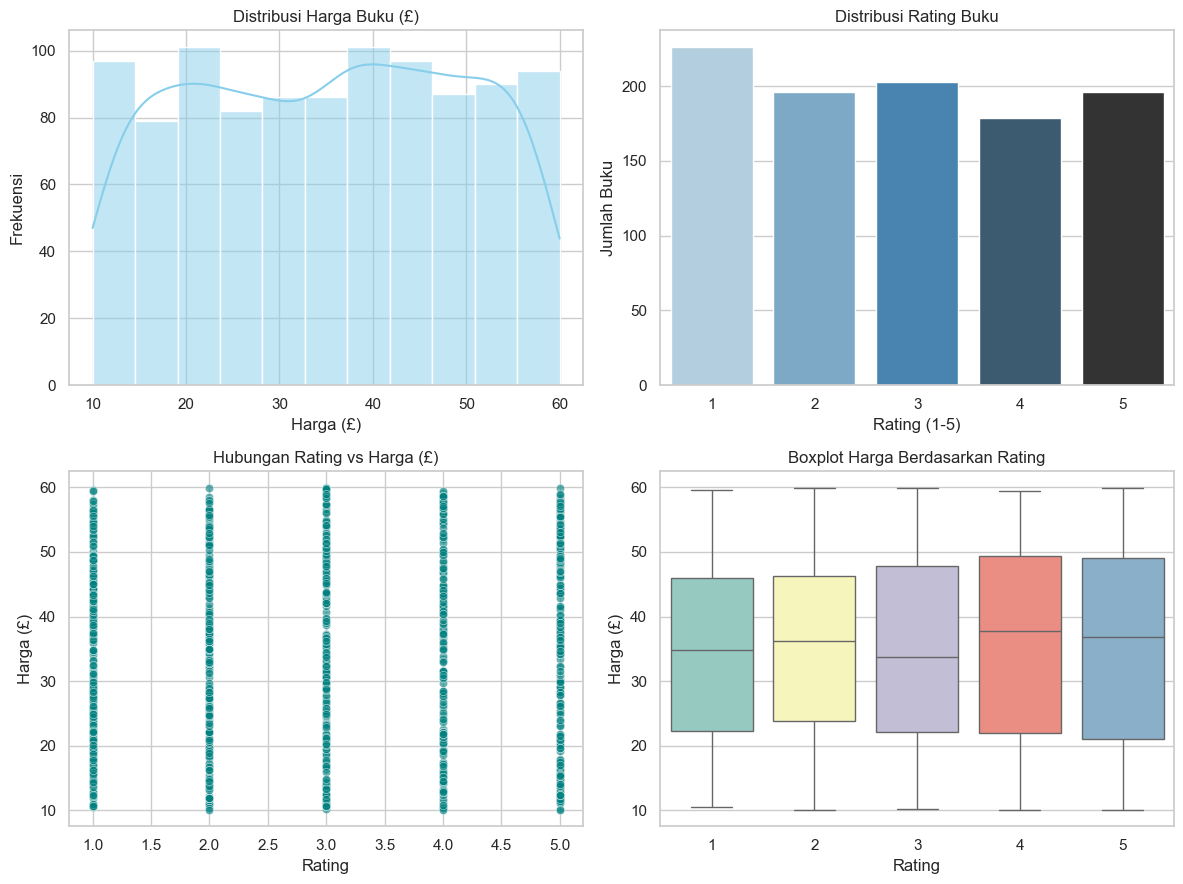

In [18]:
import warnings; warnings.filterwarnings("ignore") # opsional untuk suppress warning global

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Histogram
sns.histplot(df["harga_gbp"], kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Distribusi Harga Buku (£)"); axes[0,0].set_xlabel("Harga (£)"); axes[0,0].set_ylabel("Frekuensi")

# 2. Countplot (Ditambahkan hue & legend)
sns.countplot(x="rating", hue="rating", data=df, ax=axes[0,1], palette="Blues_d", legend=False)
axes[0,1].set_title("Distribusi Rating Buku"); axes[0,1].set_xlabel("Rating (1-5)"); axes[0,1].set_ylabel("Jumlah Buku")

# 3. Scatter Plot
sns.scatterplot(x="rating", y="harga_gbp", data=df, ax=axes[1,0], alpha=0.6, color="teal")
axes[1,0].set_title("Hubungan Rating vs Harga (£)"); axes[1,0].set_xlabel("Rating"); axes[1,0].set_ylabel("Harga (£)")

# 4. Boxplot (Ditambahkan hue & legend)
sns.boxplot(x="rating", y="harga_gbp", hue="rating", data=df, ax=axes[1,1], palette="Set3", legend=False)
axes[1,1].set_title("Boxplot Harga Berdasarkan Rating"); axes[1,1].set_xlabel("Rating"); axes[1,1].set_ylabel("Harga (£)")

plt.tight_layout(); plt.show()

### Visualisasi Data dan Interpretasi Grafik

penjelasan visualisasi dr dataset Books to Scrape berdsarkan 4 plot utama:

* **distribusi Harga Buku (£)**: histogram + KDE melht penyebaran harga buku dr £10 ampe £60 yang mana polanya cenderung *uniform distribution* alias rata banget di setiap range harga, gaada penumpukan ekstrem di harga murah atau mahal doang

* **distribusi Rating Buku**: countplot nunjukin frekuensi buku dr rating 1 ampe 5 terbagi cukup merata di kisaran 180-220 buku per kategori rating, rating 1 dikit lebih dominan tp *overall* tetep seimbang *spread*-nya

* **hubungan Rating vs Harga (£)**: scatter plot antara rating dan harga nampilin titik data yg tersebar lurus vertikal di tiap angka rating dari bawah ampe atas, melht kalo gaada korelasi linier sama sekali antara harga buku sm rating yg didapet

* **boxplot Harga Berdasarkan Rating**: melht interquartile range (IQR) dan nilai median harga di tiap rating ada di kisaran £35-£37 yang sejajar secara horizontal, garis *whisker* batas atas (£60) dan bawah (£10) sama semua di tiap rating yang makin mertegaskan kalo gaada *outlier* dan harga barang emg terdistribusi acak tanpa ngaruh ke rating